# How to Know If Your Model Is Any Good

---

## Why choosing the right metric is half the battle

You've trained a model and it reports 99% accuracy. Time to celebrate? Not so fast.

Imagine you're building a spam detector. If only 1% of emails are actually spam, a model that blindly predicts "not spam" for every single email achieves 99% accuracy — while catching exactly zero spam. The number looks great; the model is useless.

This is one of the most common traps in ML: **the metric you optimize shapes the model you get**, and the wrong metric can make a terrible model look good (or a good model look mediocre). Picking the right evaluation metric is not a formality — it's a design decision that reflects what you actually care about.

The key questions to ask before choosing a metric:

- **What kind of errors hurt the most?** In cancer screening, missing a tumor (false negative) is far worse than a false alarm (false positive). In spam filtering, the opposite is true.
- **Are the classes balanced?** If one class dominates, accuracy becomes meaningless.
- **Do you need a single number or a full picture?** Sometimes a confusion matrix tells you more than any single score.

In this notebook we'll build up from the confusion matrix through precision, recall, F1, ROC-AUC for classification, and MSE, RMSE, MAE, R² for regression — with manual implementations alongside sklearn, so there's no mystery about what each metric actually computes.

In [2]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    # Classification metrics
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc,
    precision_recall_curve, average_precision_score,
    # Regression metrics
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Classification Metrics

### 1.1 The Confusion Matrix

Every classification metric boils down to four numbers. When your model makes a prediction, exactly one of four things happens:

- The model says **positive** and it **is** positive → **True Positive (TP)** — correct catch
- The model says **negative** and it **is** negative → **True Negative (TN)** — correct rejection
- The model says **positive** but it **isn't** → **False Positive (FP)** — false alarm (Type I error)
- The model says **negative** but it **is** positive → **False Negative (FN)** — missed case (Type II error)

We arrange these in a 2×2 grid called the **confusion matrix**:

```
                  Predicted
                Pos      Neg
Actual  Pos     TP       FN
        Neg     FP       TN
```

Everything we'll cover in this section — accuracy, precision, recall, F1, ROC — is just a different way of slicing these four numbers to answer a different question.

In [3]:
def manual_tp_tn_fp_fn_calculator(y_t, y_p):
    tp, tn, fp, fn = 0, 0, 0, 0
    for i in range(len(y_p)):
        if y_t[i] == y_p[i] and y_t[i] == 1:
            tp += 1
        if y_t[i] == y_p[i] and y_t[i] == 0:
            tn += 1
        if y_t[i] != y_p[i] and y_t[i] == 1:
            fn += 1
        if y_t[i] == y_p[i] and y_t[i] == 0:
            fp += 1
    return tn, fp, fn, tp

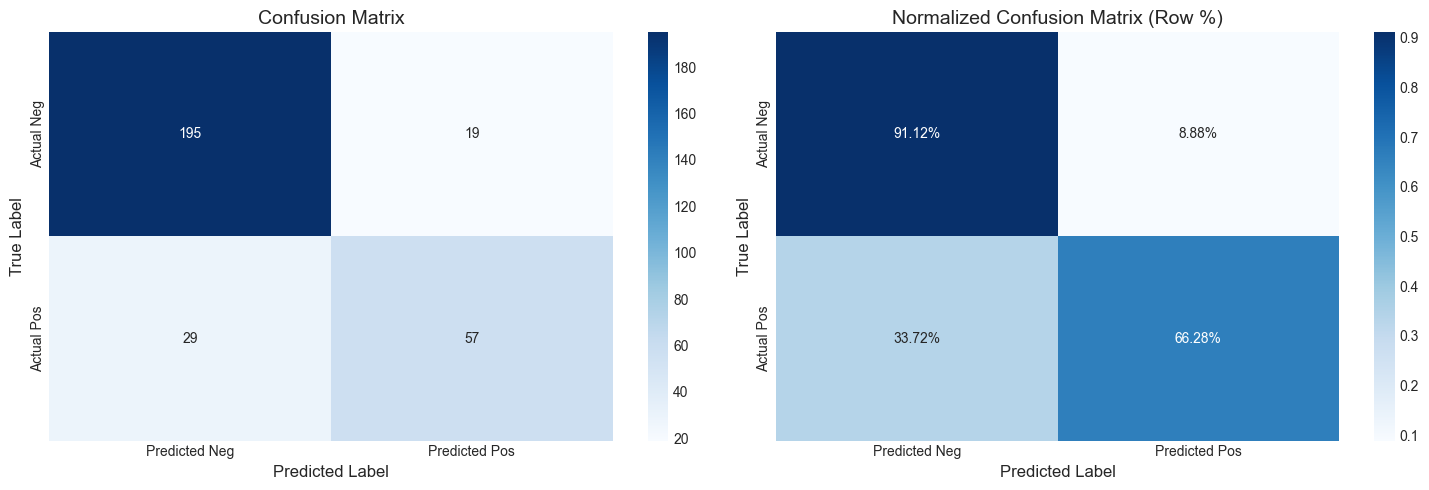


Confusion Matrix Breakdown:
True Negatives (TN):   195  (Correctly predicted negative) manual:  195
False Positives (FP):   19  (Type I Error) manual:   19
False Negatives (FN):   29  (Type II Error) manual:   29
True Positives (TP):    57  (Correctly predicted positive) manual:   57

Total predictions: 300


In [4]:
# Generate binary classification data
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                          n_redundant=5, weights=[0.7, 0.3], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
           xticklabels=['Predicted Neg', 'Predicted Pos'],
           yticklabels=['Actual Neg', 'Actual Pos'])
ax1.set_title('Confusion Matrix', fontsize=14)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

# Plot 2: Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
           xticklabels=['Predicted Neg', 'Predicted Pos'],
           yticklabels=['Actual Neg', 'Actual Pos'])
ax2.set_title('Normalized Confusion Matrix (Row %)', fontsize=14)
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
mtn, mfp, mfn, mtp = manual_tp_tn_fp_fn_calculator(y_test, y_pred)

print("\nConfusion Matrix Breakdown:")
print("=" * 50)
print(f"True Negatives (TN):  {tn:4d}  (Correctly predicted negative) manual: {tn:4d}")
print(f"False Positives (FP): {fp:4d}  (Type I Error) manual: {fp:4d}")
print(f"False Negatives (FN): {fn:4d}  (Type II Error) manual: {fn:4d}")
print(f"True Positives (TP):  {tp:4d}  (Correctly predicted positive) manual: {tp:4d}")
print(f"\nTotal predictions: {tn + fp + fn + tp}")

### 1.2 Accuracy

The simplest metric: what fraction of all predictions were correct?

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Accuracy is intuitive and easy to explain to stakeholders, but it has a critical blind spot: it treats all correct predictions as equally valuable. If 99% of your data is class A, a model that always predicts A gets 99% accuracy while being completely blind to class B.

**Rule of thumb:** accuracy is useful when classes are roughly balanced and both types of errors matter equally. The moment either condition breaks, you need something better.

In [5]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
manual_accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"Accuracy: {accuracy:.4f}")
print(f"Manual calculation: {manual_accuracy:.4f}")
print(f"\nThis means {accuracy*100:.2f}% of predictions were correct.")

Accuracy: 0.8400
Manual calculation: 0.8400

This means 84.00% of predictions were correct.


### 1.3 Precision

Precision answers: **"When the model says positive, how often is it right?"**

$$\text{Precision} = \frac{TP}{TP + FP}$$

High precision means few false alarms. This matters when the cost of a false positive is high — for example, in spam detection (blocking a legitimate email is bad) or criminal justice (wrongly convicting someone is worse than letting a guilty person go).

A model can trivially achieve perfect precision by being extremely selective: if it only predicts positive when it's absolutely sure, it'll rarely be wrong — but it'll miss a lot of true positives. That's why precision alone isn't enough.

In [6]:
# Calculate precision
precision = precision_score(y_test, y_pred)
manual_precision = tp / (tp + fp)

print(f"Precision: {precision:.4f}")
print(f"Manual calculation: {manual_precision:.4f}")
print(f"\nOf all predicted positive cases, {precision*100:.2f}% were actually positive.")
print(f"False positive rate among predictions: {(1-precision)*100:.2f}%")

Precision: 0.7500
Manual calculation: 0.7500

Of all predicted positive cases, 75.00% were actually positive.
False positive rate among predictions: 25.00%


### 1.4 Recall (Sensitivity, True Positive Rate)

Recall answers the opposite question: **"Of all the actual positives, how many did we catch?"**

$$\text{Recall} = \frac{TP}{TP + FN}$$

High recall means few missed cases. This matters when the cost of a false negative is high — in cancer screening, you'd rather flag a healthy patient for a follow-up (false positive) than miss an actual tumor (false negative).

A model can trivially achieve perfect recall by predicting positive for *everything* — but then precision drops to the base rate. Precision and recall pull in opposite directions, which is why we need to think about the tradeoff.

In [7]:
# Calculate recall
recall = recall_score(y_test, y_pred)
manual_recall = tp / (tp + fn)

print(f"Recall: {recall:.4f}")
print(f"Manual calculation: {manual_recall:.4f}")
print(f"\nOf all actual positive cases, we correctly identified {recall*100:.2f}%.")
print(f"We missed {(1-recall)*100:.2f}% of positive cases (false negatives).")

Recall: 0.6628
Manual calculation: 0.6628

Of all actual positive cases, we correctly identified 66.28%.
We missed 33.72% of positive cases (false negatives).


### 1.5 The Precision-Recall Tradeoff

There's typically a tradeoff between precision and recall:

- **High precision, low recall**: Few false positives, but miss many true positives
- **Low precision, high recall**: Catch most positives, but many false alarms

You can adjust this by changing the **decision threshold**.

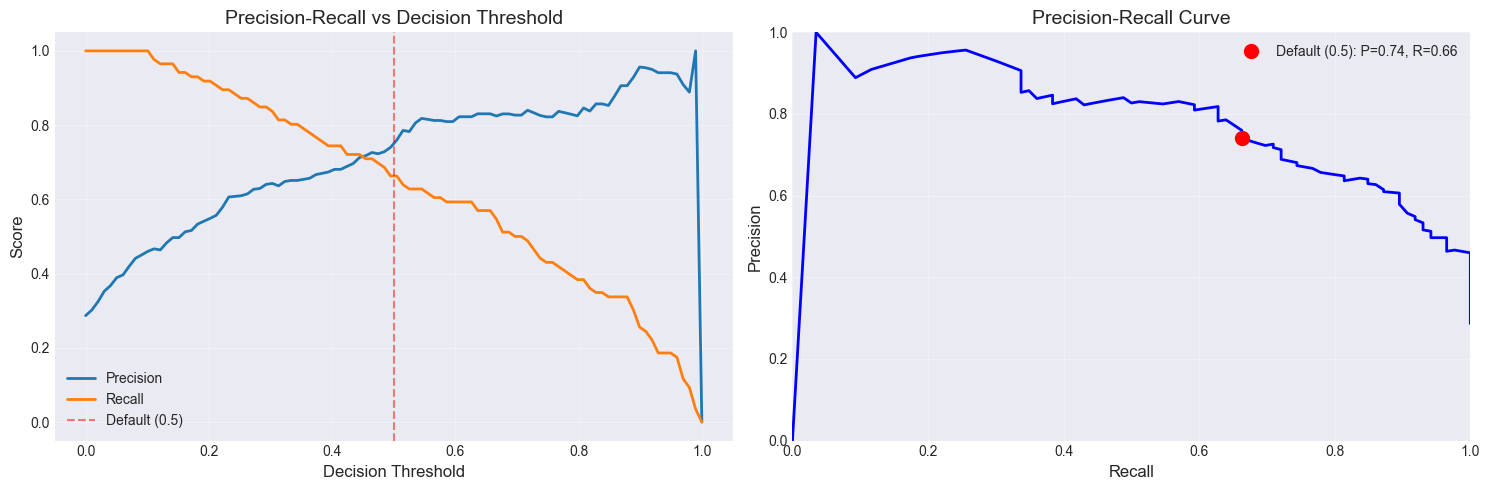


Key Observations:
- As threshold increases → Precision increases, Recall decreases
- As threshold decreases → Recall increases, Precision decreases
- The optimal threshold depends on your priorities!


In [8]:
# Test different thresholds
thresholds_test = np.linspace(0, 1, 100)
precisions = []
recalls = []

for threshold in thresholds_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Precision and Recall vs Threshold
ax1.plot(thresholds_test, precisions, label='Precision', linewidth=2)
ax1.plot(thresholds_test, recalls, label='Recall', linewidth=2)
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Precision-Recall vs Decision Threshold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
ax2.plot(recalls, precisions, linewidth=2, color='blue')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

# Mark default threshold
default_idx = np.argmin(np.abs(thresholds_test - 0.5))
ax2.plot(recalls[default_idx], precisions[default_idx], 'ro', markersize=10, 
        label=f'Default (0.5): P={precisions[default_idx]:.2f}, R={recalls[default_idx]:.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- As threshold increases → Precision increases, Recall decreases")
print("- As threshold decreases → Recall increases, Precision decreases")
print("- The optimal threshold depends on your priorities!")

### 1.6 F1 Score

If you need to condense precision and recall into one number, F1 is the standard choice. It's the **harmonic mean** of precision and recall:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Why the harmonic mean instead of a regular average? Because the harmonic mean **punishes imbalance**. If precision is 0.95 and recall is 0.10, the arithmetic mean is a respectable-sounding 0.525 — but F1 is only 0.18, which correctly reflects that the model is nearly useless at finding positives.

F1 is most useful when you care about both false positives and false negatives, and especially when classes are imbalanced (where accuracy would be misleading).

In [9]:
# Calculate F1 score
f1 = f1_score(y_test, y_pred)
manual_f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score: {f1:.4f}")
print(f"Manual calculation: {manual_f1:.4f}")
print(f"\nF1 balances precision ({precision:.4f}) and recall ({recall:.4f})")

# Compare with arithmetic mean
arithmetic_mean = (precision + recall) / 2
print(f"\nHarmonic mean (F1): {f1:.4f}")
print(f"Arithmetic mean:    {arithmetic_mean:.4f}")
print("\nF1 is lower because harmonic mean penalizes imbalance.")

F1 Score: 0.7037
Manual calculation: 0.7037

F1 balances precision (0.7500) and recall (0.6628)

Harmonic mean (F1): 0.7037
Arithmetic mean:    0.7064

F1 is lower because harmonic mean penalizes imbalance.


### 1.7 Classification Report

Sklearn provides a convenient summary of all metrics:


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.87      0.91      0.89       214
     Class 1       0.75      0.66      0.70        86

    accuracy                           0.84       300
   macro avg       0.81      0.79      0.80       300
weighted avg       0.84      0.84      0.84       300



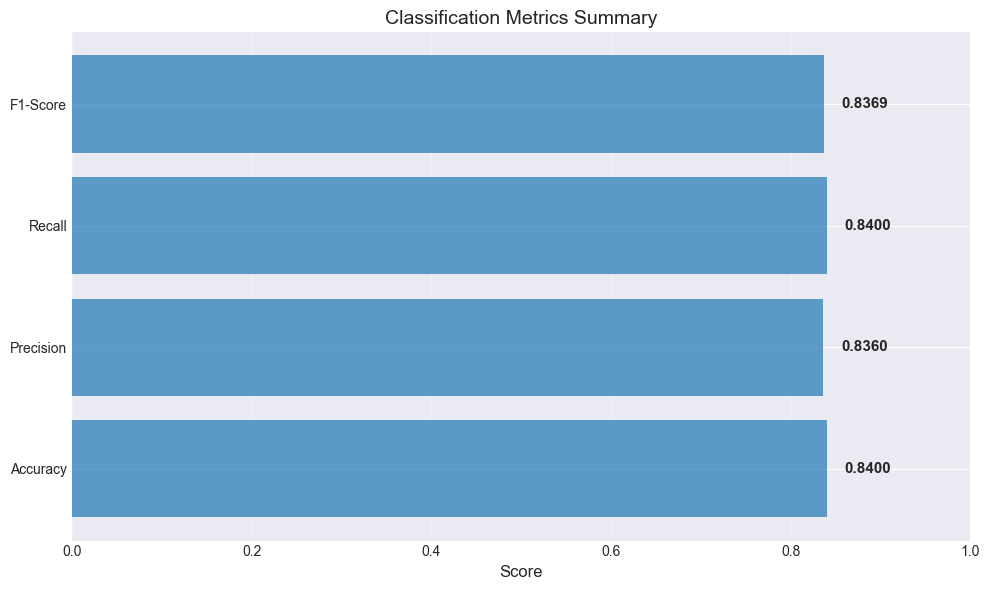

In [10]:
# Generate classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# Create visual comparison
report = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [
        report['accuracy'],
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score']
    ]
})

plt.figure(figsize=(10, 6))
bars = plt.barh(metrics_df['Metric'], metrics_df['Score'], alpha=0.7)
plt.xlabel('Score', fontsize=12)
plt.title('Classification Metrics Summary', fontsize=14)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (metric, score) in enumerate(zip(metrics_df['Metric'], metrics_df['Score'])):
    plt.text(score + 0.02, i, f'{score:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.8 ROC Curve and AUC

All the metrics above depend on a **threshold**: the cutoff probability above which we predict positive. Change the threshold and you get different precision, recall, accuracy, etc.

The **ROC curve** sidesteps this by showing performance across *all possible thresholds*. It plots the True Positive Rate (= recall) against the False Positive Rate (= FP / (FP + TN)) as the threshold sweeps from 0 to 1.

The **AUC** (Area Under the ROC Curve) collapses this into a single number:
- **AUC = 1.0**: perfect separation — there exists a threshold that gets everything right
- **AUC = 0.5**: no better than random — the model carries no signal
- **AUC < 0.5**: worse than random — your labels might be flipped

A useful interpretation: AUC is the probability that the model ranks a random positive example higher than a random negative one. This makes it a good metric for comparing models when you haven't committed to a specific operating threshold yet.

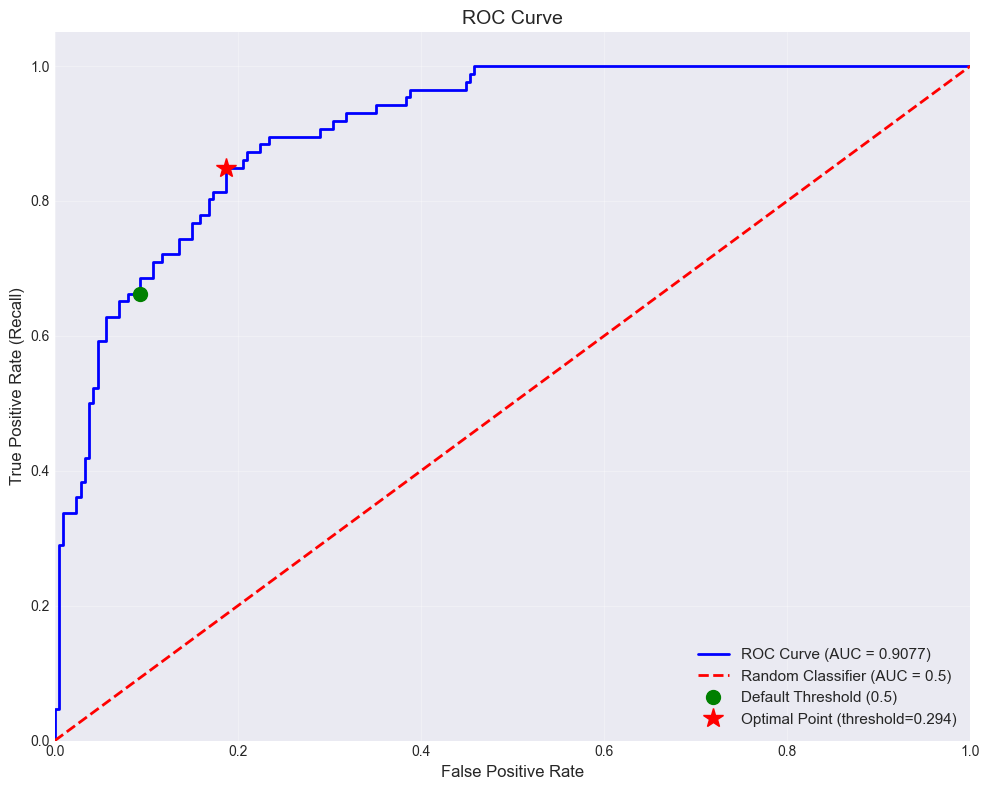


ROC-AUC Score: 0.9077
Interpretation: The model has 90.8% probability of ranking
a random positive example higher than a random negative example.

Optimal threshold: 0.294
  TPR at optimal: 0.849
  FPR at optimal: 0.187


In [11]:
# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark some key points
default_idx = np.argmin(np.abs(thresholds_roc - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, 
        label=f'Default Threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

# Add optimal point annotation
# Optimal point: closest to top-left corner
optimal_idx = np.argmax(tpr - fpr)
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'r*', markersize=15, 
        label=f'Optimal Point (threshold={thresholds_roc[optimal_idx]:.3f})')
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"Interpretation: The model has {roc_auc:.1%} probability of ranking")
print(f"a random positive example higher than a random negative example.")
print(f"\nOptimal threshold: {thresholds_roc[optimal_idx]:.3f}")
print(f"  TPR at optimal: {tpr[optimal_idx]:.3f}")
print(f"  FPR at optimal: {fpr[optimal_idx]:.3f}")

### 1.9 Handling Imbalanced Classes

When classes are severely imbalanced, accuracy becomes misleading:

Imbalanced Dataset:
Class distribution in training:
  Class 0:  6892 (98.5%)
  Class 1:   108 (1.5%)

Model Performance on Imbalanced Data:
Accuracy:  0.9883 ⚠️  (Misleading!)
Precision: 1.0000
Recall:    0.0278
F1 Score:  0.0541
ROC-AUC:   0.8336

Confusion Matrix:
[[2964    0]
 [  35    1]]


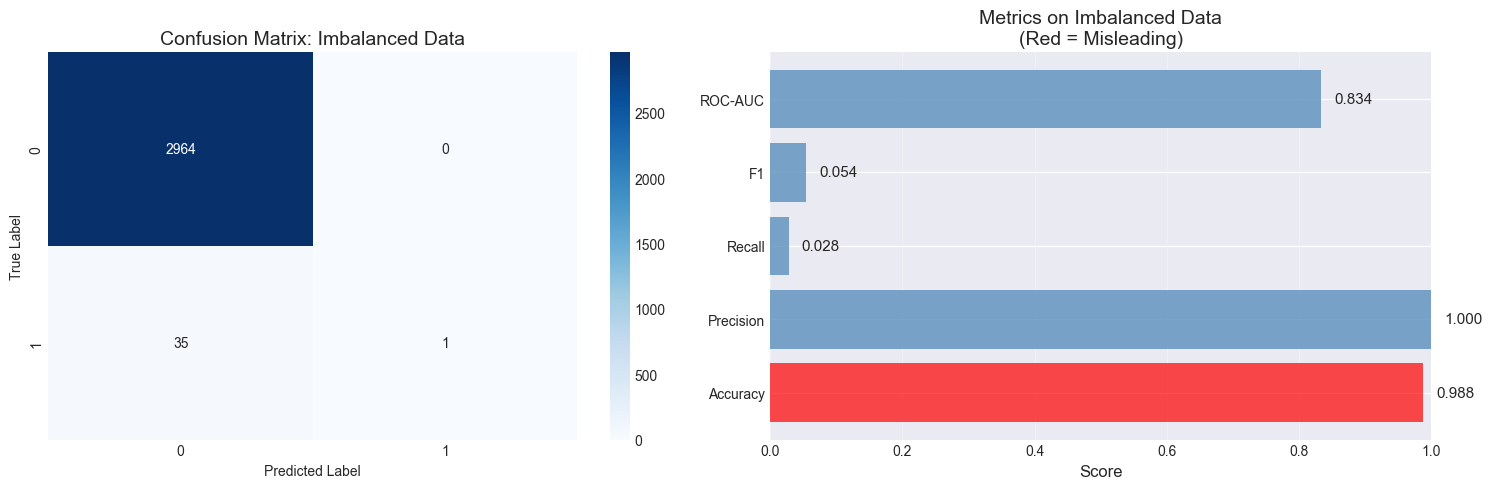


⚠️  Key Insight: Accuracy is 99% but the model is terrible at detecting
    the minority class! F1 and ROC-AUC are more informative.


In [13]:
# Create highly imbalanced dataset (99% negative, 1% positive)
X_imb, y_imb = make_classification(n_samples=10000, n_features=20, 
                                   weights=[0.99, 0.01], random_state=42)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42
)

print("Imbalanced Dataset:")
print(f"Class distribution in training:")
unique, counts = np.unique(y_train_imb, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count:5d} ({count/len(y_train_imb)*100:.1f}%)")

# Train model
model_imb = LogisticRegression(random_state=42)
model_imb.fit(X_train_imb, y_train_imb)
y_pred_imb = model_imb.predict(X_test_imb)
y_pred_proba_imb = model_imb.predict_proba(X_test_imb)[:, 1]

# Calculate metrics
print("\n" + "=" * 60)
print("Model Performance on Imbalanced Data:")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test_imb, y_pred_imb):.4f} ⚠️  (Misleading!)")
print(f"Precision: {precision_score(y_test_imb, y_pred_imb):.4f}")
print(f"Recall:    {recall_score(y_test_imb, y_pred_imb):.4f}")
print(f"F1 Score:  {f1_score(y_test_imb, y_pred_imb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_imb, y_pred_proba_imb):.4f}")

# Show confusion matrix
cm_imb = confusion_matrix(y_test_imb, y_pred_imb)
print("\nConfusion Matrix:")
print(cm_imb)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion matrix
sns.heatmap(cm_imb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Imbalanced Data', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: Metric comparison
metrics_imb = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
scores_imb = [
    accuracy_score(y_test_imb, y_pred_imb),
    precision_score(y_test_imb, y_pred_imb),
    recall_score(y_test_imb, y_pred_imb),
    f1_score(y_test_imb, y_pred_imb),
    roc_auc_score(y_test_imb, y_pred_proba_imb)
]
colors_imb = ['red' if m == 'Accuracy' else 'steelblue' for m in metrics_imb]
axes[1].barh(metrics_imb, scores_imb, color=colors_imb, alpha=0.7)
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_title('Metrics on Imbalanced Data\n(Red = Misleading)', fontsize=14)
axes[1].set_xlim(0, 1)
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, score in enumerate(scores_imb):
    axes[1].text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n⚠️  Key Insight: Accuracy is 99% but the model is terrible at detecting")
print("    the minority class! F1 and ROC-AUC are more informative.")

## 2. Regression Metrics

Classification metrics count discrete right/wrong outcomes. For regression, we need to measure **how far off** the predictions are — and it turns out the choice of "how far" matters a lot.

### 2.1 Mean Squared Error (MSE)

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

MSE squares each error before averaging. This has a key consequence: **large errors get punished disproportionately**. An error of 10 contributes 100 to the sum, while two errors of 5 each contribute only 50 total. If big mistakes are particularly bad in your application (e.g., predicting a building will withstand an earthquake when it won't), MSE is the right choice.

The downside is that MSE is in squared units (dollars² if you're predicting prices), which makes it hard to interpret directly.

MSE: 377.31
Manual calculation: 377.31


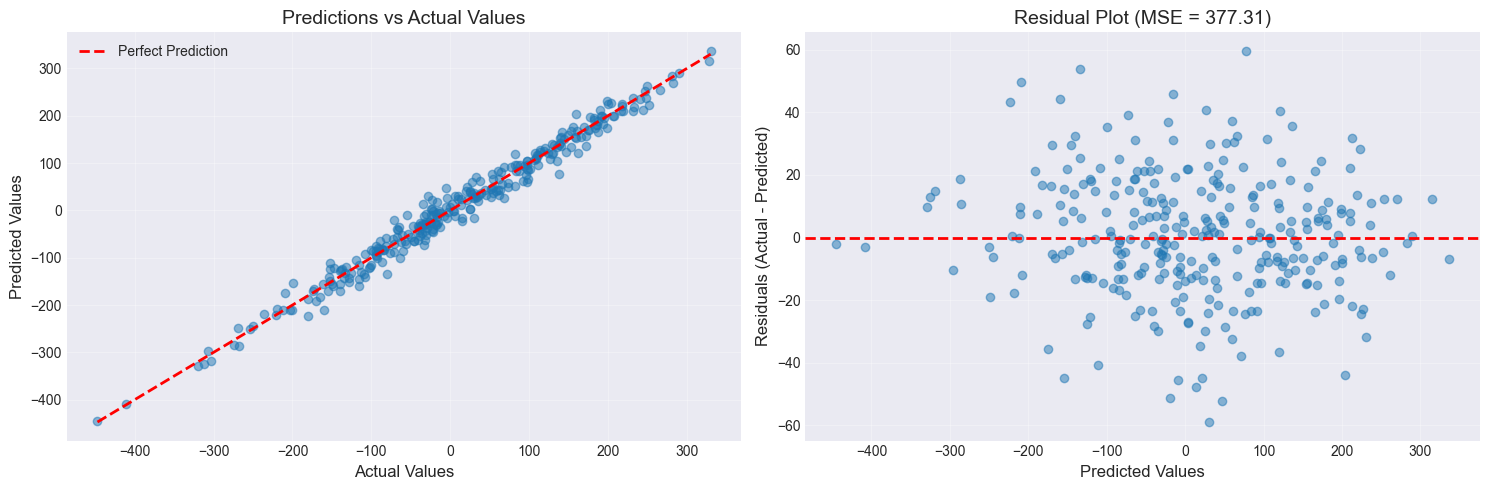

In [14]:
# Generate regression data
X_reg, y_reg = make_regression(n_samples=1000, n_features=10, noise=20, random_state=42)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Train model
model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = model_reg.predict(X_test_reg)

# Calculate MSE
mse = mean_squared_error(y_test_reg, y_pred_reg)
manual_mse = np.mean((y_test_reg - y_pred_reg)**2)

print(f"MSE: {mse:.2f}")
print(f"Manual calculation: {manual_mse:.2f}")

# Visualize predictions vs actual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Predictions vs Actual
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.5)
ax1.plot([y_test_reg.min(), y_test_reg.max()], 
        [y_test_reg.min(), y_test_reg.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Values', fontsize=12)
ax1.set_ylabel('Predicted Values', fontsize=12)
ax1.set_title('Predictions vs Actual Values', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_reg - y_pred_reg
ax2.scatter(y_pred_reg, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Values', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.set_title(f'Residual Plot (MSE = {mse:.2f})', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Root Mean Squared Error (RMSE)

**RMSE** is the square root of MSE:

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**Advantages over MSE:**
- Same units as the target variable (easier to interpret)
- Can be directly compared to the scale of the data

In [15]:
# Calculate RMSE
rmse = np.sqrt(mse)
manual_rmse = np.sqrt(np.mean((y_test_reg - y_pred_reg)**2))

print(f"RMSE: {rmse:.2f}")
print(f"Manual calculation: {manual_rmse:.2f}")
print(f"\nTarget variable range: [{y_test_reg.min():.2f}, {y_test_reg.max():.2f}]")
print(f"Target variable std: {y_test_reg.std():.2f}")
print(f"\nRMSE as % of std: {rmse/y_test_reg.std()*100:.1f}%")

RMSE: 19.42
Manual calculation: 19.42

Target variable range: [-447.17, 329.95]
Target variable std: 135.16

RMSE as % of std: 14.4%


### 2.3 Mean Absolute Error (MAE)

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

MAE treats all errors proportionally: an error of 10 costs exactly twice as much as an error of 5. No squaring, no disproportionate punishment for outliers.

This makes MAE **more robust to outliers** than MSE/RMSE. If your dataset has a few extreme values (e.g., house prices with a handful of mansions), MAE won't let those outliers dominate the metric. The trade-off is that MAE isn't differentiable at zero, which matters for some optimization algorithms but not for evaluation.

In [16]:
# Calculate MAE
mae = mean_absolute_error(y_test_reg, y_pred_reg)
manual_mae = np.mean(np.abs(y_test_reg - y_pred_reg))

print(f"MAE: {mae:.2f}")
print(f"Manual calculation: {manual_mae:.2f}")

# Compare MSE, RMSE, and MAE
print("\nComparison:")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"\nNote: RMSE > MAE when there are outliers (large errors)")
print(f"      RMSE ≈ MAE when errors are uniform")

MAE: 15.14
Manual calculation: 15.14

Comparison:
  MSE:  377.31
  RMSE: 19.42
  MAE:  15.14

Note: RMSE > MAE when there are outliers (large errors)
      RMSE ≈ MAE when errors are uniform


### 2.4 R² Score (Coefficient of Determination)

MSE, RMSE, and MAE all have a problem: their scale depends on the target variable. An MSE of 1000 might be great for predicting house prices in dollars but terrible for predicting temperature in Celsius. You need context to interpret them.

R² fixes this by comparing your model to the dumbest possible baseline — always predicting the mean:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{\text{MSE of your model}}{\text{MSE of predicting the mean}}$$

- **R² = 1.0**: your model perfectly predicts every point
- **R² = 0.0**: your model is no better than predicting the mean every time
- **R² < 0**: your model is *worse* than predicting the mean (something is seriously wrong)

R² is scale-independent and easy to explain: "the model captures 85% of the variance in the target." But beware — R² always improves as you add more features, even useless ones, which is why adjusted R² exists (though that's a topic for another day).

In [17]:
# Calculate R²
r2 = r2_score(y_test_reg, y_pred_reg)

# Manual calculation
ss_res = np.sum((y_test_reg - y_pred_reg)**2)  # Residual sum of squares
ss_tot = np.sum((y_test_reg - y_test_reg.mean())**2)  # Total sum of squares
manual_r2 = 1 - (ss_res / ss_tot)

print(f"R² Score: {r2:.4f}")
print(f"Manual calculation: {manual_r2:.4f}")
print(f"\nInterpretation: The model explains {r2*100:.2f}% of the variance in the target.")

# Compare with baseline (always predict mean)
baseline_pred = np.full_like(y_test_reg, y_test_reg.mean())
baseline_mse = mean_squared_error(y_test_reg, baseline_pred)
print(f"\nBaseline MSE (always predict mean): {baseline_mse:.2f}")
print(f"Model MSE: {mse:.2f}")
print(f"Improvement: {(1 - mse/baseline_mse)*100:.1f}%")

R² Score: 0.9793
Manual calculation: 0.9793

Interpretation: The model explains 97.93% of the variance in the target.

Baseline MSE (always predict mean): 18268.44
Model MSE: 377.31
Improvement: 97.9%


## 3. Choosing the Right Metric

### Real-World Examples:

In [19]:
# Create scenarios table
scenarios = [
    {
        'Scenario': 'Spam Detection',
        'Problem': 'Blocking real email is bad',
        'Metric': 'Precision',
        'Why': 'Minimize false positives'
    },
    {
        'Scenario': 'Cancer Screening',
        'Problem': 'Missing cancer is catastrophic',
        'Metric': 'Recall',
        'Why': 'Minimize false negatives'
    },
    {
        'Scenario': 'Fraud Detection',
        'Problem': 'Need balance',
        'Metric': 'F1 Score',
        'Why': 'Balance precision and recall'
    },
    {
        'Scenario': 'Model Selection',
        'Problem': 'Compare overall performance',
        'Metric': 'ROC-AUC',
        'Why': 'Threshold-independent'
    },
    {
        'Scenario': 'House Price Prediction',
        'Problem': 'Some very expensive houses',
        'Metric': 'MAE',
        'Why': 'Robust to outliers'
    },
    {
        'Scenario': 'Temperature Forecasting',
        'Problem': 'Penalize large errors',
        'Metric': 'MSE/RMSE',
        'Why': 'Large errors are worse'
    },
    {
        'Scenario': 'Sales Prediction',
        'Problem': 'Interpret variance explained',
        'Metric': 'R²',
        'Why': 'Scale-independent, interpretable'
    }
]

scenarios_df = pd.DataFrame(scenarios)
print("\nMetric Selection Guide: Real-World Scenarios")
print("=" * 90)
print(scenarios_df.to_string(index=False))


Metric Selection Guide: Real-World Scenarios
               Scenario                        Problem    Metric                              Why
         Spam Detection     Blocking real email is bad Precision         Minimize false positives
       Cancer Screening Missing cancer is catastrophic    Recall         Minimize false negatives
        Fraud Detection                   Need balance  F1 Score     Balance precision and recall
        Model Selection    Compare overall performance   ROC-AUC            Threshold-independent
 House Price Prediction     Some very expensive houses       MAE               Robust to outliers
Temperature Forecasting          Penalize large errors  MSE/RMSE           Large errors are worse
       Sales Prediction   Interpret variance explained        R² Scale-independent, interpretable


## Summary

### Classification Metrics

| Metric | What it answers | When to reach for it |
|--------|----------------|---------------------|
| **Accuracy** | What fraction of predictions were correct? | Balanced classes, equal error costs |
| **Precision** | When we say positive, how often are we right? | False positives are expensive |
| **Recall** | Of all actual positives, how many did we catch? | Missing positives is dangerous |
| **F1** | One number balancing precision and recall | Imbalanced classes, both error types matter |
| **ROC-AUC** | How well does the model rank positives above negatives? | Model comparison, threshold not yet chosen |

### Regression Metrics

| Metric | What it measures | Key property |
|--------|-----------------|-------------|
| **MSE** | Average squared error | Punishes large errors hard |
| **RMSE** | Square root of MSE | Same units as target, interpretable |
| **MAE** | Average absolute error | Robust to outliers |
| **R²** | Variance explained vs. mean baseline | Scale-independent |

### The big takeaways

**No metric is universally correct.** Every metric encodes an assumption about what matters, and choosing the wrong one can lead you to optimize for the wrong thing. The right metric is the one that aligns with the real-world cost of errors in your specific problem.

When in doubt: **look at multiple metrics together**, and always inspect the confusion matrix. A single number can hide important failure modes — the confusion matrix cannot.

## Review Questions

1. What's the difference between precision and recall?
2. Why is accuracy misleading for imbalanced datasets?
3. When would you prefer high precision over high recall?
4. What does ROC-AUC measure and why is it useful?
5. What's the difference between MSE and MAE?
6. How do you interpret an R² score of 0.85?
7. Why might you choose MAE over RMSE?
8. What's the relationship between F1 score, precision, and recall?